# Task 3 — Fine-Tuning an Open-Source LLM for Medical Conversations (LoRA)

**Goal:** turn a general-purpose small LLaMA-based model into a domain-specific medical assistant, and compare its answers **before** vs **after** fine-tuning.

| Requirement | Where in this notebook |
|---|---|
| 1. Load a small pre-trained model | Step 2 (TinyLlama-1.1B-Chat, LLaMA architecture) |
| 2. Prepare dataset in instruction format | Step 4 (ChatDoctor-HealthCareMagic, chat/instruction format) |
| 3. Apply LoRA (PEFT) | Step 6 |
| 4. Train for a few epochs | Step 7 (3 epochs) |
| 5. Save the fine-tuned adapter | Step 8 |
| 6. Compare before vs after | Steps 3, 9, 10 |

> **Runtime:** Colab → Runtime → Change runtime type → **T4 GPU**. Total time is roughly 20–30 minutes.

> ⚠️ Educational project only. The model is **not** a substitute for a real doctor.

## 1️⃣ Install & imports

In [1]:
# torchao is not used here, and an old preinstalled version breaks recent peft versions -> remove it
!pip uninstall -y -q torchao
!pip install -q -U transformers peft accelerate datasets
# After the FIRST run of this cell: Runtime -> Restart session, then run all cells again from the top.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 87.1 MB/s eta 0:00:00


In [2]:
import os, random, inspect, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (AutoModelForCausalLM, AutoTokenizer, TrainingArguments,
                          Trainer, DataCollatorForSeq2Seq, set_seed)
from peft import LoraConfig, get_peft_model, PeftModel

warnings.filterwarnings("ignore")
SEED = 42
set_seed(SEED)

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


## 2️⃣ Load a small pre-trained model

We use **TinyLlama-1.1B-Chat**: it has the LLaMA architecture (so it matches the task), it is small enough for a free T4 GPU, and it is already a *general-purpose* chat model, so it is a fair "before" baseline.

In [3]:
MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,   # T4 does not support bf16, so we use fp16
    device_map="auto",
)
print(f"Loaded {MODEL_ID} with {model.num_parameters()/1e6:.0f}M parameters")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded TinyLlama/TinyLlama-1.1B-Chat-v1.0 with 1100M parameters


## 3️⃣ Test the model **before** fine-tuning

We use the same system prompt for the base model and the fine-tuned model, so the only difference is the LoRA adapter.
Greedy decoding (`do_sample=False`) is used so the comparison is reproducible.

In [4]:
SYSTEM_PROMPT = ("You are a helpful medical assistant. Answer the patient's question "
                 "clearly and safely, and advise seeing a doctor when necessary.")

def build_prompt(question):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

@torch.no_grad()
def generate_answer(m, question, max_new_tokens=200):
    m.eval()
    prompt = build_prompt(question)
    inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to(m.device)
    out = m.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

# The same test questions are used before and after fine-tuning
test_questions = [
    "I have had a dry cough and a mild sore throat for 5 days. Should I be worried?",
    "I get headaches almost every afternoon. What could be causing this?",
    "My 4-year-old has a fever of 38.5C since yesterday. What should I do?",
    "I feel pain in my lower back after sitting for long hours. Any advice?",
    "Is it safe to take ibuprofen every day for joint pain?",
]

before_answers = {q: generate_answer(model, q) for q in test_questions}

for q, a in before_answers.items():
    print("Q:", q)
    print("BEFORE:", a)
    print("-" * 100)

[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

Q: I have had a dry cough and a mild sore throat for 5 days. Should I be worried?
BEFORE: Yes, it is recommended to consult with your healthcare provider if you have been experiencing symptoms of a respiratory infection such as a dry cough or a mild sore throat for more than 5 days. These symptoms can indicate a more serious condition that requires medical attention. It is also essential to follow any instructions provided by your healthcare provider regarding self-care measures, such as avoiding contact with others, staying home from work or school, and using an air purifier or humidifier to improve air quality. If you have any underlying health conditions or are taking medications, it is essential to discuss these with your healthcare provider before making any decisions about treatment.
----------------------------------------------------------------------------------------------------
Q: I get headaches almost every afternoon. What could be causing this?
BEFORE: Certainly! Headache

## 4️⃣ Prepare the dataset in instruction format

Dataset: [`lavita/ChatDoctor-HealthCareMagic-100k`](https://huggingface.co/datasets/lavita/ChatDoctor-HealthCareMagic-100k) — real patient questions with doctor answers.
We only use a small subset so training is fast. **Quality > quantity** (from the lecture), so we filter out very short/very long samples.

In [5]:
raw = load_dataset("lavita/ChatDoctor-HealthCareMagic-100k", split="train")
print(raw)
print(raw.column_names)
print("\nSample:\n", raw[0])

README.md:   0%|          | 0.00/542 [00:00<?, ?B/s]

data/train-00000-of-00001-5e7cb295b9cff0(…):   0%|          | 0.00/70.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/112165 [00:00<?, ? examples/s]

Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 112165
})
['instruction', 'input', 'output']

Sample:
 {'instruction': "If you are a doctor, please answer the medical questions based on the patient's description.", 'input': 'I woke up this morning feeling the whole room is spinning when i was sitting down. I went to the bathroom walking unsteadily, as i tried to focus i feel nauseous. I try to vomit but it wont come out.. After taking panadol and sleep for few hours, i still feel the same.. By the way, if i lay down or sit down, my head do not spin, only when i want to move around then i feel the whole world is spinning.. And it is normal stomach discomfort at the same time? Earlier after i relieved myself, the spinning lessen so i am not sure whether its connected or coincidences.. Thank you doc!', 'output': 'Hi, Thank you for posting your query. The most likely cause for your symptoms is benign paroxysmal positional vertigo (BPPV), a type of peripheral verti

In [6]:
# Columns: 'input' = patient question, 'output' = doctor answer
def is_good(ex):
    q, a = ex["input"].strip(), ex["output"].strip()
    return 20 <= len(q) <= 800 and 100 <= len(a) <= 1200

clean = raw.filter(is_good).shuffle(seed=SEED)

N_TRAIN, N_EVAL = 1500, 100
train_raw = clean.select(range(N_TRAIN))
eval_raw  = clean.select(range(N_TRAIN, N_TRAIN + N_EVAL))
print(len(train_raw), len(eval_raw))

Filter:   0%|          | 0/112165 [00:00<?, ? examples/s]

1500 100


In [7]:
MAX_LEN = 512

def tokenize_example(ex):
    question, answer = ex["input"].strip(), ex["output"].strip()

    prompt_text = build_prompt(question)                       # system + user + <|assistant|>
    full_text   = prompt_text + answer + tokenizer.eos_token   # + doctor answer + </s>

    prompt_ids = tokenizer(prompt_text, add_special_tokens=False)["input_ids"]
    full_ids   = tokenizer(full_text,   add_special_tokens=False)["input_ids"][:MAX_LEN]

    # Loss only on the answer: mask the prompt tokens with -100
    labels = [-100] * len(prompt_ids) + full_ids[len(prompt_ids):]
    labels = labels[:len(full_ids)]
    return {"input_ids": full_ids, "attention_mask": [1] * len(full_ids), "labels": labels}

train_data = train_raw.map(tokenize_example, remove_columns=train_raw.column_names)
eval_data  = eval_raw.map(tokenize_example,  remove_columns=eval_raw.column_names)

# Look at one formatted example
ex = train_raw[0]
print(build_prompt(ex["input"]) + ex["output"])

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

<|system|>
You are a helpful medical assistant. Answer the patient's question clearly and safely, and advise seeing a doctor when necessary.</s>
<|user|>
my 11 month old son has had a fever for the last two days (temp 38-39) and tonight I have noticed two lumps behind his left ear and one behind his right. His temperature at the moment is 38.1 despite having panadol 4 hours ago. Should I take him to emergency tonight or wait until tomorrow? He took his fluids today but refused diet which is unusual for him.</s>
<|assistant|>
Hi, welcome to froufrou history I understand that there is mild grade fever with small lumps being both ears. The lumps are quite a common finding in kids if this age. About the fever, kindly sponge the child from top to bottom with normal tap water with each fever spike, along with fever medication. If fever continues even after 49-72 hours or if child had high fever the visit your pediatrician in OLD. No need to rush to ED


## 5️⃣ Evaluation loss of the base model (quantitative "before")

In [8]:
data_collator = DataCollatorForSeq2Seq(tokenizer, padding=True, label_pad_token_id=-100, pad_to_multiple_of=8)

# 'eval_strategy' in new transformers, 'evaluation_strategy' in old ones
eval_key = "eval_strategy" if "eval_strategy" in inspect.signature(TrainingArguments.__init__).parameters else "evaluation_strategy"

## 6️⃣ Apply LoRA (Parameter-Efficient Fine-Tuning)

Instead of updating all 1.1B weights, LoRA adds small low-rank matrices to the attention and MLP projections, and only those are trained.

In [9]:
lora_config = LoraConfig(
    r=16,                # rank = capacity of the adapter
    lora_alpha=32,       # scaling factor
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

model = get_peft_model(model, lora_config)

# Keep the trainable LoRA weights in fp32 (required for fp16 mixed-precision training)
for p in model.parameters():
    if p.requires_grad:
        p.data = p.data.float()

model.print_trainable_parameters()

trainable params: 12,615,680 || all params: 1,112,664,064 || trainable%: 1.1338


## 7️⃣ Train for 3 epochs

In [10]:
OUTPUT_DIR = "tinyllama-medical-checkpoints"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,      # effective batch size = 16
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=14,                    # ~5% of 282 total steps (replaces warmup_ratio)
    weight_decay=0.01,
    max_grad_norm=0.3,
    fp16=True,
    logging_steps=10,
    save_strategy="epoch",
    save_total_limit=1,
    report_to="none",
    seed=SEED,
    **{eval_key: "epoch"},
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=eval_data,
    data_collator=data_collator,
)

model.config.use_cache = False
base_eval = trainer.evaluate()          # adapter is zero-initialised, so this equals the base model
print("Eval loss BEFORE fine-tuning:", round(base_eval["eval_loss"], 4))

Training Loss,Validation Loss,Epoch
No log,2.911644,0


Eval loss BEFORE fine-tuning: 2.9116


In [11]:
train_result = trainer.train()
print(train_result.metrics)

Epoch,Training Loss,Validation Loss
1,2.239961,2.157521
2,2.022985,2.093325
3,1.853868,2.095150


{'train_runtime': 806.9963, 'train_samples_per_second': 5.576, 'train_steps_per_second': 0.349, 'total_flos': 1.0357822220009472e+16, 'train_loss': 2.0864621798197427, 'epoch': 3.0}


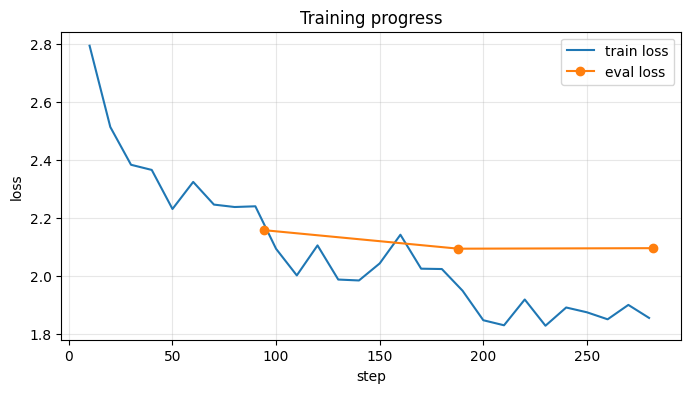

Training Loss,Validation Loss,Epoch
1.853868,2.095150,3


Eval loss  before: 2.9116  ->  after: 2.0952


In [12]:
# Loss curves
logs = pd.DataFrame(trainer.state.log_history)

train_logs = logs.dropna(subset=["loss"])
eval_logs  = logs.dropna(subset=["eval_loss"])

plt.figure(figsize=(8, 4))
plt.plot(train_logs["step"], train_logs["loss"], label="train loss")
plt.plot(eval_logs["step"], eval_logs["eval_loss"], "o-", label="eval loss")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.title("Training progress"); plt.grid(alpha=.3)
plt.show()

final_eval = trainer.evaluate()
print(f"Eval loss  before: {base_eval['eval_loss']:.4f}  ->  after: {final_eval['eval_loss']:.4f}")

## 8️⃣ Save the fine-tuned adapter

Only the small LoRA adapter is saved (a few MB), not the whole 1.1B model.

In [13]:
ADAPTER_DIR = "./tinyllama-medical-lora-adapter"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

for f in sorted(os.listdir(ADAPTER_DIR)):
    print(f"{f:35s} {os.path.getsize(os.path.join(ADAPTER_DIR, f))/1e6:8.2f} MB")

README.md                               0.01 MB
adapter_config.json                     0.00 MB
adapter_model.safetensors              50.50 MB
chat_template.jinja                     0.00 MB
tokenizer.json                          3.62 MB
tokenizer_config.json                   0.00 MB


## 9️⃣ Reload the saved adapter and test **after** fine-tuning

We load a fresh copy of the base model and attach the saved adapter, to prove that the saved adapter works on its own.

In [14]:
del model, trainer
torch.cuda.empty_cache()

base_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16, device_map="auto")
ft_model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
ft_model.eval()

after_answers = {q: generate_answer(ft_model, q) for q in test_questions}

for q in test_questions:
    print("Q:", q)
    print("AFTER:", after_answers[q])
    print("-" * 100)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

Q: I have had a dry cough and a mild sore throat for 5 days. Should I be worried?
AFTER: Hello, Welcome to Chat Doctor.come have evaluated your query thoroughly. I understand your concern. You may have viral illness like cold or flu. It is not serious condition. If you have fever with chills, rigors, loss of appetite, decreased sense of smell and taste, difficulty in breathing etc., then you should consult your doctor. You can take antibiotics like tab amoxicillin 875\u00a0mg twice daily for 5 days along with tab paracetamol 500\u00a0mg once daily for 3 days. Take plenty of fluids and warm saline gargles. Avoid hot and spicy food. Avoid touching your nose and mouth. Wear a mask while going out. Regards...
----------------------------------------------------------------------------------------------------
Q: I get headaches almost every afternoon. What could be causing this?
AFTER: Hello, Thank you for asking at Chat Doctor. I went through your query. You have not mentioned the exact lo

## 🔟 Side-by-side comparison: before vs after

In [15]:
comparison = pd.DataFrame({
    "Question": test_questions,
    "Before fine-tuning": [before_answers[q] for q in test_questions],
    "After fine-tuning":  [after_answers[q]  for q in test_questions],
})
comparison["Words (before)"] = comparison["Before fine-tuning"].str.split().str.len()
comparison["Words (after)"]  = comparison["After fine-tuning"].str.split().str.len()

pd.set_option("display.max_colwidth", None)
display(comparison)

comparison.to_csv("before_vs_after_comparison.csv", index=False)

,Question,Before fine-tuning,After fine-tuning,Words (before),Words (after)
0,I have had a dry cough and a mild sore throat for 5 days. Should I be worried?,"Yes, it is recommended to consult with your healthcare provider if you have been experiencing symptoms of a respiratory infection such as a dry cough or a mild sore throat for more than 5 days. These symptoms can indicate a more serious condition that requires medical attention. It is also essential to follow any instructions provided by your healthcare provider regarding self-care measures, such as avoiding contact with others, staying home from work or school, and using an air purifier or humidifier to improve air quality. If you have any underlying health conditions or are taking medications, it is essential to discuss these with your healthcare provider before making any decisions about treatment.","Hello, Welcome to Chat Doctor.come have evaluated your query thoroughly. I understand your concern. You may have viral illness like cold or flu. It is not serious condition. If you have fever with chills, rigors, loss of appetite, decreased sense of smell and taste, difficulty in breathing etc., then you should consult your doctor. You can take antibiotics like tab amoxicillin 875\u00a0mg twice daily for 5 days along with tab paracetamol 500\u00a0mg once daily for 3 days. Take plenty of fluids and warm saline gargles. Avoid hot and spicy food. Avoid touching your nose and mouth. Wear a mask while going out. Regards...",113,103
1,I get headaches almost every afternoon. What could be causing this?,"Certainly! Headaches can be caused by various factors, including:\n\n1. Stress: Chronic stress can cause tension in your neck and shoulders, leading to muscle tension and headaches. Try taking deep breaths or practicing relaxation techniques like yoga or meditation to reduce stress levels.\n\n2. Sleep disorders: If you have sleep problems, such as insomnia or sleep apnea, it can lead to headaches. Make sure you are getting enough restful sleep each night.\n\n3. Food intolerances or allergies: Some foods, such as dairy products, nuts, and shellfish, can trigger headaches. It's best to consult with a healthcare professional if you suspect you have a food allergy or intolerance.\n\n4. Excessive caffeine consumption: Caffeine can cause headaches in some people. Limit","Hello, Thank you for asking at Chat Doctor. I went through your query. You have not mentioned the exact location of headache. Headache can occur due to many reasons like- 1. Migraine - This is a severe headache which occurs in frequency and intensity. It may cause nausea, vomiting, sensitivity to light or sound, tingling sensation in hands and feet, blurred vision etc.2. Tension headache - This type of headache occurs due to muscle tension in neck and shoulders.3. Post concussion headache - This headache occurs after a blow to the head.4. Cluster headache - This headache occurs in clusters and usually occurs on one side only.5. Sinus headache - This headache occurs due to sinusitis.6. Hormonal changes - This headache occurs due to hormonal imbalance.7. Stress - This headache",119,130
2,My 4-year-old has a fever of 38.5C since yesterday. What should I do?,"If your 4-year-old child has a fever of 38.5°C (101.3°F) or higher, it is essential to seek medical attention immediately. Here are some steps you can take:\n\n1. Check for any signs of infection, such as redness, swelling, or pain around the eyes, nose, or mouth. If you notice any of these symptoms, call your doctor immediately.\n\n2. Wash your hands with soap and water for at least 20 seconds before handling the child.\n\n3. Keep the child hydrated by offering them cool drinks like water, milk, or iced tea.\n\n4. Use a humidifier in the room to help keep the air moist and reduce the risk of infection.\n\n5. Monitor the child closely for any signs of dehydration, such as dry skin, dizziness,","Hi, dairy have gone through your question. I can understand your concern. Y

In [16]:
# Same comparison in a readable format (good for screenshots in the report)
for i, q in enumerate(test_questions, 1):
    print(f"### Question {i}: {q}\n")
    print("BEFORE FINE-TUNING:\n", before_answers[q], "\n")
    print("AFTER FINE-TUNING:\n",  after_answers[q],  "\n")
    print("=" * 100)

### Question 1: I have had a dry cough and a mild sore throat for 5 days. Should I be worried?

BEFORE FINE-TUNING:
 Yes, it is recommended to consult with your healthcare provider if you have been experiencing symptoms of a respiratory infection such as a dry cough or a mild sore throat for more than 5 days. These symptoms can indicate a more serious condition that requires medical attention. It is also essential to follow any instructions provided by your healthcare provider regarding self-care measures, such as avoiding contact with others, staying home from work or school, and using an air purifier or humidifier to improve air quality. If you have any underlying health conditions or are taking medications, it is essential to discuss these with your healthcare provider before making any decisions about treatment. 

AFTER FINE-TUNING:
 Hello, Welcome to Chat Doctor.come have evaluated your query thoroughly. I understand your concern. You may have viral illness like cold or flu. It is

In [17]:
# Ask your own question
my_question = "I have a burning feeling in my chest after eating. What could it be?"
print("BASE MODEL:\n", end="")
with ft_model.disable_adapter():
    print(generate_answer(ft_model, my_question))
print("\nFINE-TUNED MODEL:\n" + generate_answer(ft_model, my_question))

[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BASE MODEL:


[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


If you have a burning feeling in your chest after eating, it is common for people to experience this sensation. It can be caused by various factors such as:

1. Acid reflux: This occurs when stomach acid backs up into the esophagus, causing discomfort and pain. You may want to try taking medications or lifestyle changes to manage this condition.

2. Heartburn: This is a symptom of acid reflux that causes a burning sensation in the chest. You may want to try reducing the amount of food you eat or drinking water before bedtime to help alleviate this issue.

3. Nausea: If you feel nauseous after eating, it could be due to a variety of reasons, including:
   - Food allergies or intolerances
   - Gastrointestinal issues (such as ulcers)

FINE-TUNED MODEL:
Hello, Welcome to Chat Doctor. I have gone through your query and understand your concern. Burning sensation in chest can be due to many reasons like heart diseases, lung diseases, bronchitis, asthma, allergic reactions, infection etc. So 